In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
os.getcwd()

'C:\\Users\\Тима'

In [4]:
#Для начала соберем инфу о таблице
df = pd.read_csv('employee_promotion_prediction.csv')
df.head()

,employee_id,age,gender,education_level,marital_status,city_tier,department,employment_type,years_at_company,years_in_current_role,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
0,1,50,Female,Master,Married,Tier1,Finance,Full-time,10,4,...,137633.720337,7.587737,16743.979863,7532.711623,0.930558,1,66.545499,97.588693,39.989458,0
1,2,36,Male,Bachelor,Married,Tier1,Sales,Full-time,9,5,...,114499.406460,10.372718,9074.413744,7694.310517,0.962302,7,81.979508,59.021333,46.484556,0
2,3,29,Female,Bachelor,Married,Tier2,Engineering,Full-time,7,5,...,124233.224752,10.115308,11807.910102,6380.645687,0.891287,1,100.000000,52.992147,38.850858,0
3,4,42,Male,Bachelor,Married,Tier1,Operations,Full-time,4,4,...,100896.326509,9.800044,8496.840118,7046.402195,1.000000,1,67.679942,67.707899,14.262315,0
4,5,40,Female,Master,Married,Tier1,Operations,Full-time,2,2,...,93054.051809,7.501102,15099.354711,4557.907600,0.896275,1,79.903505,64.384274,44.233443,0


In [5]:
#Null отсутствуют и типы объектов норм
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   employee_id                 100000 non-null  int64  
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  object 
 3   education_level             100000 non-null  object 
 4   marital_status              100000 non-null  object 
 5   city_tier                   100000 non-null  object 
 6   department                  100000 non-null  object 
 7   employment_type             100000 non-null  object 
 8   years_at_company            100000 non-null  int64  
 9   years_in_current_role       100000 non-null  int64  
 10  years_since_last_promotion  100000 non-null  int64  
 11  team_size                   100000 non-null  int64  
 12  performance_score           100000 non-null  float64
 13  performance_las

In [6]:
df.describe()

,employee_id,age,years_at_company,years_in_current_role,years_since_last_promotion,team_size,performance_score,performance_last_year,performance_two_years_ago,manager_rating,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,40.558140,5.489030,2.750630,2.749650,11.014010,70.097429,68.166798,65.102153,3.302642,...,101729.791058,7.401439,10409.710839,5658.466284,0.928158,1.993690,69.916845,67.907766,50.011404,0.100000
std,28867.657797,10.951788,3.481758,2.746004,2.733337,4.910633,14.717013,13.867294,11.773939,0.765938,...,36260.885391,2.029034,2311.368587,1264.375203,0.046578,1.415977,14.719348,15.665689,19.714147,0.300002
min,1.000000,22.000000,0.000000,0.000000,0.000000,3.000000,40.000000,40.000000,40.000000,1.000000,...,27616.720722,0.000000,1945.900012,788.905587,0.727631,0.000000,20.000000,20.000000,0.000000,0.000000
25%,25000.750000,31.000000,3.000000,1.000000,1.000000,7.000000,59.499890,58.357646,56.954026,2.769433,...,83242.514699,6.029638,8812.946506,4809.857296,0.896236,1.000000,59.887391,57.184464,36.534728,0.000000
50%,50000.500000,41.000000,5.000000,2.000000,2.000000,11.000000,69.980013,68.033605,65.018847,3.302663,...,96923.478362,7.399610,10410.582882,5661.913481,0.930238,2.000000,70.025028,68.032234,50.043370,0.000000
75%,75000.250000,50.000000,7.000000,4.000000,4.000000,15.000000,80.596442,77.791895,73.121749,3.837462,...,112448.432831,8.773342,12002.845048,6508.183945,0.963801,3.000000,80.159887,78.895916,63.409152,0.000000
max,100000.000000,59.000000,30.000000,28.000000,29.000000,19.000000,100.000000,100.000000,100.000000,5.000000,...,663817.278916,15.996288,19615.455082,10846.763857,1.000000,12.000000,100.000000,100.000000,100.000000,1.000000


<Axes: ylabel='salary'>

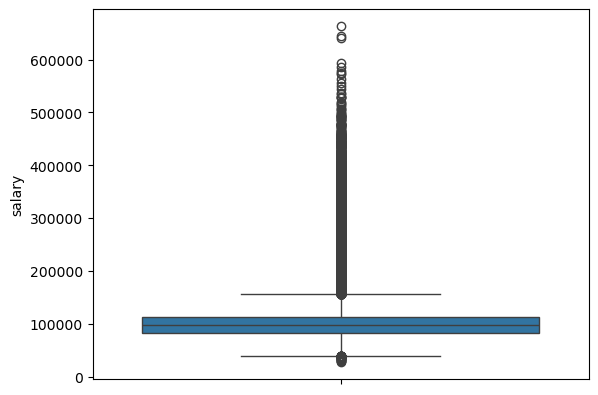

In [7]:
#Есть аномальные суммы по salary
sns.boxplot(df.salary)

In [8]:
#Хочу изучить подробнее людей с наивысшими salary, возможно есть причины высокий з/п
df.nlargest(10, 'salary')

,employee_id,age,gender,education_level,marital_status,city_tier,department,employment_type,years_at_company,years_in_current_role,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
85367,85368,44,Female,Bachelor,Single,Tier2,Engineering,Full-time,6,5,...,663817.278916,10.659099,14197.328357,7492.577506,0.932438,3,83.021669,78.501373,50.682195,0
98602,98603,33,Female,Master,Single,Tier1,Engineering,Full-time,16,15,...,645463.512270,7.900414,8650.693454,6596.303863,0.883191,1,83.325182,44.302386,67.353922,0
93116,93117,40,Female,Master,Single,Tier1,Sales,Full-time,12,8,...,641855.573439,7.328594,11612.363839,6036.455998,0.871133,2,72.752429,98.206200,39.595729,0
45684,45685,52,Female,Master,Married,Tier1,Engineering,Full-time,3,2,...,593479.828792,6.770277,10335.144562,5064.515846,0.885811,3,46.076582,44.205927,40.713020,1
4422,4423,52,Female,Bachelor,Single,Tier1,Engineering,Full-time,10,1,...,586833.982732,9.039084,8969.296111,2924.702590,0.970222,1,78.269534,91.242528,55.881532,0
57415,57416,30,Male,PhD,Single,Tier1,Marketing,Full-time,5,3,...,578171.869396,4.775753,8223.304675,4210.836972,0.960222,2,71.849763,100.000000,39.411880,0
78822,78823,33,Female,Bachelor,Single,Tier1,Engineering,Full-time,9,3,...,573836.702952,6.755641,9963.137532,4471.337556,1.000000,1,86.142246,72.531142,48.739013,0
59159,59160,42,Female,Bachelor,Married,Tier1,Engineering,Full-time,4,3,...,572302.548943,10.292473,14681.273243,5593.713825,0.935628,2,57.540396,71.233628,52.441056,1
87875,87876,36,Female,Bachelor,Single,Tier1,Finance,Full-time,7,7,...,562743.492561,8.185071,14178.691506,6297.126250,0.916303,3,85.396855,64.695192,97.925434,1
76073,76074,41,Male,Bachelor,Single,Tier1,Finance,Full-time,12,8,...,554830.841540,8.587770,12203.128386,7325.861629,0.905491,2,43.937070,39.641182,24.049773,0


array([[<Axes: title={'center': 'salary'}>]], dtype=object)

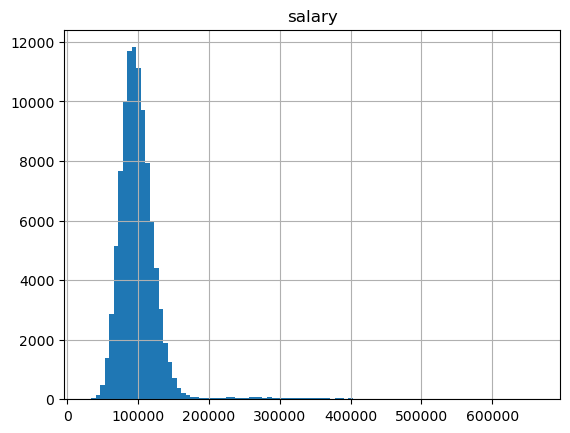

In [9]:
#Распределение нормальное, хоть и есть явные хвосты
df.hist('salary', bins=100)

In [10]:
df['salary'].mean()

np.float64(101729.79105771337)

In [11]:
df['salary'].median()

96923.47836241529

In [12]:
'''
В целом значения медианы и среднего практически идентичны
Значит хвосты не велики
Коэфициент вариации (ниже) не сильно критичный

Делаю вывод, что данные сохраняем
'''
df['salary'].std() / df['salary'].mean()

np.float64(0.3564431324739081)

<Axes: ylabel='salary_increase_percent'>

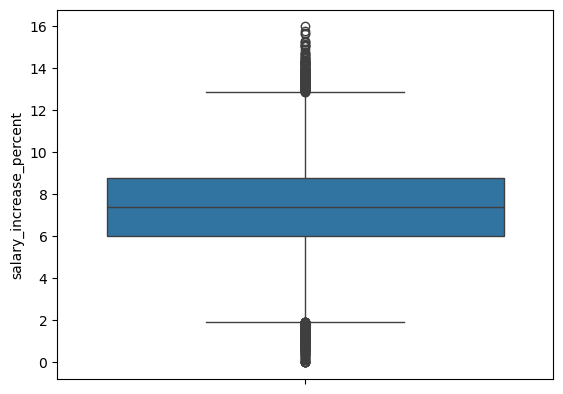

In [13]:
#Стала интересна колонка с увеличением з/п
sns.boxplot(df.salary_increase_percent)

In [14]:
#Дубликаты отсутствуют
df.duplicated().sum()

np.int64(0)

In [15]:
#Посмотрим на соотношение, кого повышали хотя бы раз и людей без повышения
df['promoted'].value_counts(normalize=True)

promoted
0    0.9
1    0.1
Name: proportion, dtype: float64

In [16]:
'''
Хочу выявить потенциальные взаимосвязи с колонкой 'promoted'
Проверю соотношение этих взаимосвязей через df.promoted.mean()
'''
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   employee_id                 100000 non-null  int64  
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  object 
 3   education_level             100000 non-null  object 
 4   marital_status              100000 non-null  object 
 5   city_tier                   100000 non-null  object 
 6   department                  100000 non-null  object 
 7   employment_type             100000 non-null  object 
 8   years_at_company            100000 non-null  int64  
 9   years_in_current_role       100000 non-null  int64  
 10  years_since_last_promotion  100000 non-null  int64  
 11  team_size                   100000 non-null  int64  
 12  performance_score           100000 non-null  float64
 13  performance_las

In [17]:
#Далее пройдусь по всем столбцам и оставлю потенциальные взаимосвязи
df.groupby('promoted')['performance_score'].mean()

promoted
0    69.114688
1    78.942095
Name: performance_score, dtype: float64

In [18]:
df.groupby('promoted')['performance_score'].median()

promoted
0    68.928881
1    79.566177
Name: performance_score, dtype: float64

In [19]:
df.groupby('department')['promoted'].mean()

department
Engineering    0.332135
Finance        0.079700
HR             0.029016
Marketing      0.086853
Operations     0.044530
Sales          0.109806
Support        0.019589
Name: promoted, dtype: float64

In [20]:
df.groupby('promoted')['projects_completed'].mean()

promoted
0    5.258756
1    7.118600
Name: projects_completed, dtype: float64

In [21]:
df.groupby('promoted')['kpi_achievement_percent'].mean()

promoted
0    68.859483
1    78.890386
Name: kpi_achievement_percent, dtype: float64

In [22]:
df.groupby('promoted')['tasks_completed'].mean()

promoted
0    34.833609
1    43.328287
Name: tasks_completed, dtype: float64

In [23]:
df.groupby('promoted')['employee_engagement_score'].mean()

promoted
0    69.545585
1    73.258179
Name: employee_engagement_score, dtype: float64

In [24]:
df.groupby('promoted')['employee_engagement_score'].std()

promoted
0    14.723035
1    14.258249
Name: employee_engagement_score, dtype: float64

In [25]:
df.groupby('promoted')['job_satisfaction_score'].mean()

promoted
0    67.442535
1    72.094839
Name: job_satisfaction_score, dtype: float64

In [26]:
df.groupby('promoted')['job_satisfaction_score'].std()

promoted
0    15.662980
1    15.057249
Name: job_satisfaction_score, dtype: float64

In [27]:
'''
Промежуточный вывод:
наибольшее внимание стоит уделить performance_score и kpi_achievement_percent
Есть вероятность что tasks_completed хоть и высока, но зависима от kpi

Перехожу в SQL
'''

'\nПромежуточный вывод:\nнаибольшее внимание стоит уделить performance_score и kpi_achievement_percent\nЕсть вероятность что tasks_completed хоть и высока, но зависима от kpi\n\nПерехожу в SQL\n'

In [42]:
df.to_csv('employee_clean.csv', index=False)

In [1]:
#В процессе переноса в SQL SMS 21 было несоответствие типа данных и значений в колонке - overtime_hours 
#Пробовал изменить данные в notebook, но это не помогало
#Проблему решил способом - перевел данные колонки в VARCHAR, а затем обратно в float